# L0.4 — Matrices

Hands-on notebook for the lesson [`0-4-matrices.mdx`](../../llm-quest-theory/level-0/0-4-matrices.mdx).

> **Learning objectives**
> - View a matrix as a linear transformation acting on vectors.
> - Become fluent with matrix multiplication, rank, and transpose in NumPy.
> - Recognize that a "linear layer" `y = Wx + b` is really just a matrix multiplication.

## Connection to the theory
Covers **§1–§5** of the `.mdx`. Remember: `Q = X W_Q` in attention is also just a matrix multiplication. Mastering this lesson means you already have the "skeleton" of a Transformer.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Multiply a 2x2 matrix by a 2D vector
Try the 4 matrices listed in the theory table and observe how they transform the unit square.

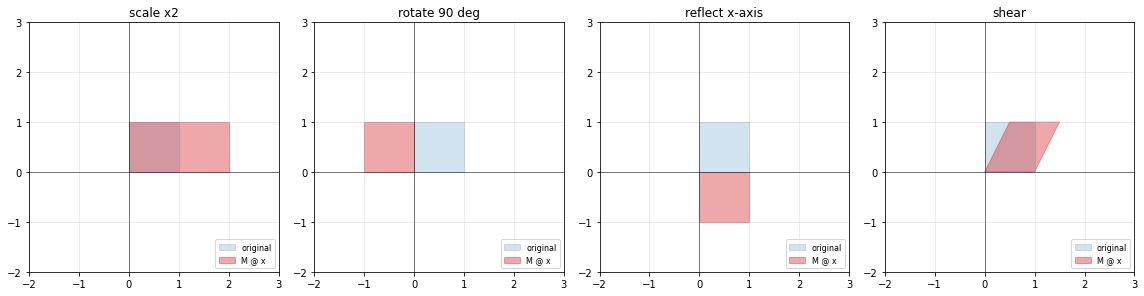

In [2]:
unit_square = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1],
    [0, 0],
]).T  # shape (2, 5)

transforms = {
    "scale x2":       np.array([[2, 0], [0, 1]]),
    "rotate 90 deg":  np.array([[0, -1], [1, 0]]),
    "reflect x-axis": np.array([[1, 0], [0, -1]]),
    "shear":          np.array([[1, 0.5], [0, 1]]),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, M) in zip(axes, transforms.items()):
    transformed = M @ unit_square
    ax.fill(unit_square[0], unit_square[1], alpha=0.2, color="tab:blue", label="original")
    ax.fill(transformed[0], transformed[1], alpha=0.4, color="tab:red", label="M @ x")
    ax.set_xlim(-2, 3); ax.set_ylim(-2, 3); ax.set_aspect("equal")
    ax.grid(alpha=0.3); ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
    ax.set_title(name); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

## 2. Order matters: `AB != BA`

In [3]:
A = transforms["rotate 90 deg"]
B = transforms["shear"]

print("A @ B =\n", A @ B)
print("B @ A =\n", B @ A)
print("Equal?", np.allclose(A @ B, B @ A))

A @ B =
 [[ 0.  -1. ]
 [ 1.   0.5]]
B @ A =
 [[ 0.5 -1. ]
 [ 1.   0. ]]
Equal? False


## 3. General matmul — verify the formula

$$C_{ij} = \sum_k A_{ik} B_{kj}$$

Re-implement it with a loop and compare against NumPy's `A @ B`.

In [4]:
def matmul_naive(A, B):
    m, n = A.shape
    n2, p = B.shape
    assert n == n2, "cols of A must match rows of B"
    C = np.zeros((m, p))
    for i in range(m):
        for j in range(p):
            C[i, j] = sum(A[i, k] * B[k, j] for k in range(n))
    return C

A3 = np.random.randn(3, 4)
B3 = np.random.randn(4, 2)
print("Matches numpy?", np.allclose(matmul_naive(A3, B3), A3 @ B3))

Matches numpy? True


## 4. Transpose, rank, identity

In [5]:
M = np.array([[1, 2, 3],
              [2, 4, 6],   # this row = 2 * row 1 -> rank drops
              [0, 1, 0]])

print("M =\n", M)
print("M^T =\n", M.T)
print("rank(M) =", np.linalg.matrix_rank(M))
print("I @ M == M?", np.allclose(np.eye(3) @ M, M))

M =
 [[1 2 3]
 [2 4 6]
 [0 1 0]]
M^T =
 [[1 2 0]
 [2 4 1]
 [3 6 0]]
rank(M) = 2
I @ M == M? True


## 5. Linear layer `y = Wx + b` for a whole batch
Given a batch `X` of shape `(B, in_dim)`, weight matrix `W` of shape `(out_dim, in_dim)`, and bias `b`, we have `Y = X @ W.T + b` producing `(B, out_dim)`.

In [6]:
B_size, in_dim, out_dim = 8, 5, 3
X = np.random.randn(B_size, in_dim)
W = np.random.randn(out_dim, in_dim)
b = np.random.randn(out_dim)

Y = X @ W.T + b
print("X.shape =", X.shape, " W.shape =", W.shape, " Y.shape =", Y.shape)

# Check: for a single sample the classic formula y = Wx + b holds
x0 = X[0]
y0_manual = W @ x0 + b
print("first sample matches?", np.allclose(Y[0], y0_manual))

X.shape = (8, 5)  W.shape = (3, 5)  Y.shape = (8, 3)
first sample matches? True


## 6. Preview: `Q = X W_Q` in attention
Simulate building Q, K, V from one sequence of `T=4` tokens with `d=6` embedding dims.

In [7]:
T, d, d_k = 4, 6, 3
X = np.random.randn(T, d)
W_Q = np.random.randn(d, d_k)
W_K = np.random.randn(d, d_k)
W_V = np.random.randn(d, d_k)

Q = X @ W_Q
K = X @ W_K
V = X @ W_V
scores = Q @ K.T / np.sqrt(d_k)   # (T, T)
print("Q.shape =", Q.shape)
print("scores (pre-softmax) =\n", np.round(scores, 2))

Q.shape = (4, 3)
scores (pre-softmax) =
 [[-0.43  2.18 -3.7   0.63]
 [ 1.48  0.42 -0.5  -0.79]
 [ 1.83  0.81 -3.28  0.4 ]
 [ 3.13  1.52 -3.4  -0.78]]


We will add softmax and masking in lesson 4-2. Takeaway from this notebook: every step above is just a matrix multiplication plus one division.

## Quick checks

In [8]:
assert (transforms["rotate 90 deg"] @ np.array([1, 0]) == np.array([0, 1])).all()
assert np.linalg.matrix_rank(np.eye(3)) == 3
assert np.allclose(matmul_naive(np.eye(3), np.eye(3)), np.eye(3))
print("OK")

OK


## Reflection questions

1. Why does a matrix with `rank < n` cause trouble when solving `Mx = y`?
2. What is the difference between the "feature dimension" (columns) and the "sample dimension" (rows) in a batch matrix `X`?
3. If we use a square `W` with `det = 0`, what happens to the geometric transformation?

## References
- Source theory: [`0-4-matrices.mdx`](../../llm-quest-theory/level-0/0-4-matrices.mdx)
- 3Blue1Brown — *Essence of Linear Algebra* (episodes on linear transformations)